# Market-Method GLM for Motor Premium

This notebook builds a **GLM premium model** using linked motor insurance tables.

## Scope
- Build a premium GLM with a **limited conventional feature set**.
- **Exclude EV-specific/advanced factors** to emulate current market approach (no EV special treatment).
- Evaluate:
  1. Premium prediction quality (2025 holdout).
  2. Insurance company underwriting profit metrics.
  3. Gen Z premium rate and Gen Z profitability view.

## Modeling choices — Frequency × Severity

Per CAS Monograph *Generalized Linear Models for Insurance Rating* (Goldburd-Khare-Tevet 2025, §2.7.1–§2.7.2):

**Pure Premium = Frequency × Severity**

| Component | GLM spec | Target | Data | Offset |
|---|---|---|---|---|
| **Frequency** | Poisson + log link | `claim_count` | All 100k policies | `log(exposure)` |
| **Severity** | Gamma + log link | `incurred / claim_count` | Claimants only (~12%) | None |

### Why split rather than a single Tweedie?

Tweedie (p ∈ (1,2)) is a compound Poisson-Gamma, mathematically equivalent, but it bundles the two signals into one set of coefficients.  
Separate models reveal **which factors affect frequency vs. severity differently** — a central actuarial finding:

- `driver_age` — young drivers crash more often (**frequency**), but their cars are cheaper to repair (**severity** may actually be lower)
- `log_sum_insured` — vehicle value has little bearing on crash rate (**frequency** ≈ neutral) but directly drives repair/replacement cost (**severity** ↑)
- `ncd_pct` — claims-history discount summarises past frequency (**frequency** signal) but does not predict future claim size

Separate AIC/BIC, p-values and deviance per component enable independent actuarial review and rate-filing transparency.

### Database tables used

| Table | Role |
|---|---|
| `policies` | Policy-level observations — frequency target (`claim_count`) and exposure |
| `claims` | Claim-level records → aggregated per policy as `incurred_amount_eval` (severity target) |
| `claim_frequency` | **Vehicle-model-level** historical frequency lookup → enrichment feature `log_veh_hist_freq_rate` |
| `claim_severity` | **Vehicle-model-level** historical severity lookup → enrichment feature `log_veh_hist_avg_severity` |
| `vehicles` | Vehicle attributes (engine size, type) |
| `expenses` | Commission rate, fixed expense loading, trending factors |

### Gross Premium
> `indicated_office = ((freq_pred × sev_pred × 1.08) + fixed_expense × exposure) / (1 − commission_rate − target_profit)`
> 
> *Note: A 15% target profit margin and an 8% inflation trend were applied to generate the final indicated premium.*

In [1]:
import os
import numpy as np
import pandas as pd

import psycopg2
from dotenv import load_dotenv

# it provides GLM offsets, p-values, AIC/BIC, deviance, and unbiased coefficient estimates.
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")

In [2]:
load_dotenv()


def get_pg_connection():
    db_url = os.getenv("DATABASE_URL") or os.getenv("SUPABASE_DB_URL")
    if db_url:
        return psycopg2.connect(db_url)

    return psycopg2.connect(
        dbname=os.getenv("dbname", os.getenv("DB_NAME", "postgres")),
        user=os.getenv("user", os.getenv("DB_USER")),
        password=os.getenv("password", os.getenv("DB_PASSWORD")),
        host=os.getenv("host", os.getenv("DB_HOST")),
        port=os.getenv("port", os.getenv("DB_PORT", "5432")),
        sslmode=os.getenv("sslmode", os.getenv("DB_SSLMODE", "require")),
    )


In [3]:
SQL_FLAT = r"""
WITH claim_rollup AS (
    -- Aggregate claims to policy level
    SELECT
        c.policy_id,
        COUNT(*)::int          AS claim_record_count,
        SUM(COALESCE(c.incurred_amount, 0))::numeric AS claim_incurred_from_claims
    FROM public.claims c
    GROUP BY c.policy_id
),

-- Vehicle-model historical frequency rate (Goldburd-Khare-Tevet: vehicle group factor)
-- Aggregated across all perils, age bands, and locations for this vehicle × coverage_type.
-- Used as a continuous lookup feature: log_veh_hist_freq_rate in the frequency GLM.
veh_hist_freq AS (
    SELECT
        vehicle_id,
        coverage_type,
        CASE WHEN SUM(total_exposure) > 0
             THEN SUM(total_claims)::numeric / SUM(total_exposure)
             ELSE NULL END AS veh_hist_freq_rate
    FROM public.claim_frequency
    GROUP BY vehicle_id, coverage_type
),

-- Vehicle-model historical average severity
-- Aggregated across all perils and sum-insured bands.
-- Used as a continuous lookup feature: log_veh_hist_avg_severity in the severity GLM.
veh_hist_sev AS (
    SELECT
        vehicle_id,
        coverage_type,
        CASE WHEN SUM(claim_count) > 0
             THEN SUM(total_claim_amount)::numeric / SUM(claim_count)
             ELSE NULL END AS veh_hist_avg_severity
    FROM public.claim_severity
    GROUP BY vehicle_id, coverage_type
)

SELECT
    p.policy_id,
    p.underwriting_year,
    p.coverage_type,
    p.driver_age,
    p.driver_gender,
    p.marital_status,
    p.location,
    p.vehicle_age,
    p.sum_insured,
    p.policy_premium,
    p.exposure,
    p.claim_count,
    p.total_claim_amount,
    p.incurred_amount AS policy_incurred_amount,
    p.ncd_pct,
    p.flood_risk_zone,
    p.theft_risk_zone,

    v.engine_capacity_cc,
    v.make,
    v.model,
    v.fuel_type,
    v.adas_level,
    v.ncap_rating,

    e.commission_rate,
    e.fixed_expense_per_policy,
    e.trending_factor,

    COALESCE(cr.claim_record_count, 0)                                 AS claim_record_count,
    COALESCE(cr.claim_incurred_from_claims, p.incurred_amount, 0)      AS incurred_amount_eval,

    -- Vehicle-model-level historical lookup features
    -- (from claim_frequency + claim_severity tables; NULL if no historical data)
    hf.veh_hist_freq_rate,
    hs.veh_hist_avg_severity

FROM public.policies p
JOIN  public.vehicles  v  ON p.vehicle_id      = v.vehicle_id
LEFT JOIN public.expenses  e  ON p.underwriting_year = e.calendar_year
LEFT JOIN claim_rollup   cr ON p.policy_id       = cr.policy_id
LEFT JOIN veh_hist_freq  hf ON p.vehicle_id      = hf.vehicle_id
                             AND p.coverage_type  = hf.coverage_type
LEFT JOIN veh_hist_sev   hs ON p.vehicle_id      = hs.vehicle_id
                             AND p.coverage_type  = hs.coverage_type
"""


In [4]:
with get_pg_connection() as conn:
    df_raw = pd.read_sql_query(SQL_FLAT, conn)

print(f"Loaded rows: {len(df_raw):,}")
print(f"Columns: {df_raw.shape[1]}")
df_raw.head(3)


/var/folders/l0/b8r5tpvs1492yl7ctsw38pzm0000gn/T/ipykernel_60519/3208057221.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_raw = pd.read_sql_query(SQL_FLAT, conn)


Loaded rows: 100,000
Columns: 30


,policy_id,underwriting_year,coverage_type,driver_age,driver_gender,marital_status,location,vehicle_age,sum_insured,policy_premium,exposure,claim_count,total_claim_amount,policy_incurred_amount,ncd_pct,flood_risk_zone,theft_risk_zone,engine_capacity_cc,make,model,fuel_type,adas_level,ncap_rating,commission_rate,fixed_expense_per_policy,trending_factor,claim_record_count,incurred_amount_eval,veh_hist_freq_rate,veh_hist_avg_severity
0,06b3a0ac-ea9e-46d3-8fec-22103a1d80a0,2021,Comprehensive,25,F,Single,Rural,0,"109,623.7800","1,403.4800",0.4900,0,0.0000,0.0000,0.0000,Medium,Medium,0,BYD,Atto 3 Extended Range,Electric,2,0,0.1000,150.0000,1.0000,0,0.0000,0.2067,"4,048.7248"
1,53592a7a-cfbb-4099-a537-aab2ba83c752,2021,Comprehensive,27,M,Married,Rural,0,"137,887.1500","2,064.0900",0.3900,0,0.0000,0.0000,0.0000,Medium,High,0,Chery,iCaur 03 AWD,Electric,2,0,0.1000,150.0000,1.0000,0,0.0000,0.1852,"8,499.5386"
2,ae4e727c-ced4-4edb-b626-de5ea31eb5b1,2021,Comprehensive,59,F,Married,Urban,6,"32,438.0700",700.0000,0.4500,0,0.0000,0.0000,0.0000,Low,Medium,1986,Toyota,Noah 2.0 S-Z,Petrol,2,0,0.1000,150.0000,1.0000,0,0.0000,0.1806,"4,140.3122"


In [5]:
df = df_raw.copy()

numeric_cols = [
    "underwriting_year", "driver_age", "vehicle_age", "sum_insured", "policy_premium",
    "exposure", "claim_count", "total_claim_amount", "policy_incurred_amount", "ncd_pct",
    "engine_capacity_cc", "commission_rate", "fixed_expense_per_policy", "trending_factor",
    "claim_record_count", "incurred_amount_eval", "ncap_rating",
    "veh_hist_freq_rate", "veh_hist_avg_severity",
]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["sum_insured"]          = df["sum_insured"].clip(lower=1)
df["policy_premium"]       = df["policy_premium"].clip(lower=1)
df["exposure"]             = df["exposure"].clip(lower=1e-6)
df["engine_capacity_cc"]   = df["engine_capacity_cc"].clip(lower=1)
df["incurred_amount_eval"] = df["incurred_amount_eval"].clip(lower=0)
df["claim_count"]          = df["claim_count"].clip(lower=0).fillna(0).astype(int)

df["log_sum_insured"]        = np.log(df["sum_insured"])
df["log_engine_capacity_cc"] = np.log(df["engine_capacity_cc"])

# Vehicle-model-level lookup features (from claim_frequency + claim_severity tables).
df["log_veh_hist_freq_rate"]    = np.log(df["veh_hist_freq_rate"].clip(lower=1e-4))
df["log_veh_hist_avg_severity"] = np.log(df["veh_hist_avg_severity"].clip(lower=1.0))

df["birth_year"] = df["underwriting_year"] - df["driver_age"]
df["is_gen_z"]   = df["birth_year"].between(1997, 2012)

# Frequency features: factors affecting HOW OFTEN a claim occurs
#   - driver_age, ncd_pct → behavioural / experience signal
#   - vehicle_age         → mechanical deterioration risk
#   - log_engine_capacity_cc → vehicle performance proxy
#   - log_veh_hist_freq_rate → vehicle model's observed claim rate (vehicle group factor)

freq_numeric_features = [
    "ncd_pct",
    "log_engine_capacity_cc",
    "log_veh_hist_freq_rate",
]

# Severity features: factors affecting HOW MUCH is paid when a claim occurs
#   - log_sum_insured     → vehicle value drives repair / total-loss cost
#   - vehicle_age         → older vehicles may be cheaper to repair but harder to source parts
#   - driver_age          → some evidence younger drivers have higher total-loss rates
#   - log_engine_capacity_cc → higher-powered vehicles cost more to repair
#   - log_veh_hist_avg_severity → vehicle model's observed average claim cost
sev_numeric_features = [
    "log_sum_insured",
    "log_engine_capacity_cc",
    "log_veh_hist_avg_severity",
]

# Categorical features used in BOTH models
market_categorical_features = [
    "coverage_type",
    "location",
    "flood_risk_zone",
    "theft_risk_zone",
]

all_model_numeric = list(dict.fromkeys(freq_numeric_features + sev_numeric_features))

excluded_features = [
    "fuel_type", "adas_level", "make", "model",
    "ncap_rating", "total_claim_amount", "claim_record_count",
]

print("Frequency model numeric features :", freq_numeric_features)
print("Severity  model numeric features :", sev_numeric_features)
print("Categorical features (both)      :", market_categorical_features)
print("Excluded (examples)              :", excluded_features)

Frequency model numeric features : ['ncd_pct', 'log_engine_capacity_cc', 'log_veh_hist_freq_rate']
Severity  model numeric features : ['log_sum_insured', 'log_engine_capacity_cc', 'log_veh_hist_avg_severity']
Categorical features (both)      : ['coverage_type', 'location', 'flood_risk_zone', 'theft_risk_zone']
Excluded (examples)              : ['fuel_type', 'adas_level', 'make', 'model', 'ncap_rating', 'total_claim_amount', 'claim_record_count']


In [6]:
model_df = df.copy()

for c in market_categorical_features:
    model_df[c] = model_df[c].astype("string").fillna("Unknown")

required_cols = list(dict.fromkeys(
    all_model_numeric
    + market_categorical_features
    + [
        "policy_premium", "underwriting_year",
        "incurred_amount_eval", "sum_insured", "exposure",
        "claim_count",
        "commission_rate", "fixed_expense_per_policy",
        "is_gen_z", "driver_age",
    ]
))

model_df = model_df[required_cols].dropna(subset=["underwriting_year"])
model_df = model_df[model_df["exposure"] > 0]

train_df = model_df[model_df["underwriting_year"] <= 2024].copy()
test_df  = model_df[model_df["underwriting_year"] == 2025].copy()

if test_df.empty:
    test_df  = model_df.sample(frac=0.2, random_state=42)
    train_df = model_df.drop(test_df.index)

# Impute numeric features using *train* medians only — no data leakage into test
train_medians = {c: train_df[c].median() for c in all_model_numeric}
for c in all_model_numeric:
    train_df[c] = train_df[c].fillna(train_medians[c])
    test_df[c]  = test_df[c].fillna(train_medians[c])

train_df["log_exposure"] = np.log(train_df["exposure"])
test_df["log_exposure"]  = np.log(test_df["exposure"])

print(f"Train rows : {len(train_df):,}")
print(f"Test rows  : {len(test_df):,}")
print(f"Train claimants (claim_count > 0): {(train_df['claim_count'] > 0).sum():,} "
      f"({(train_df['claim_count'] > 0).mean()*100:.1f}%)")
print(f"Test  claimants (claim_count > 0): {(test_df['claim_count']  > 0).sum():,} "
      f"({(test_df['claim_count']  > 0).mean()*100:.1f}%)")
print()
print(train_df["underwriting_year"].value_counts().sort_index())

Train rows : 80,000
Test rows  : 20,000
Train claimants (claim_count > 0): 9,791 (12.2%)
Test  claimants (claim_count > 0): 2,621 (13.1%)

underwriting_year
2021    20000
2022    20000
2023    20000
2024    20000
Name: count, dtype: int64


In [7]:
# ── Two-part GLM: Frequency × Severity ────────────
#
# PART 1 — Frequency GLM (Poisson + log link)
#   Target  : claim_count  (≥0 integer; ~88% zeros)
#   Offset  : log(exposure) → constrains E[claims_i] = exposure_i × exp(Xβ_freq)
#             so the model learns the RATE per unit exposure, not raw count
#   Data    : ALL policies (zeros and claimants)
#   Family  : Poisson — canonical for count data
#
# PART 2 — Severity GLM (Gamma + log link)
#   Target  : incurred_amount_eval / claim_count  (avg claim size, RM)
#   Offset  : none — target is already a per-claim amount
#   Data    : claimants ONLY (claim_count > 0)
#   Family  : Gamma — right-skewed, strictly positive continuous
#
# COMBINED
#   pure_premium_i = E[claim_count_i] × E[avg_claim_size_i]
#                  = exposure_i × exp(Xβ_freq) × exp(Xβ_sev)
#
# The independence of frequency and severity components is the standard
# actuarial assumption under the compound Poisson-Gamma model.
# Key insight: different factors explain each component → separate relativities
# per component give cleaner pricing signals than a single Tweedie coefficient.

freq_terms   = freq_numeric_features + [f"C({c})" for c in market_categorical_features]
sev_terms    = sev_numeric_features  + [f"C({c})" for c in market_categorical_features]

freq_formula = "claim_count        ~ " + " + ".join(freq_terms)
sev_formula  = "avg_claim_severity ~ " + " + ".join(sev_terms)

# ── 1. Frequency GLM ─────────────────────────────────────────────────────────
glm_freq = smf.glm(
    formula = freq_formula,
    data    = train_df,
    family  = sm.families.Poisson(link=sm.families.links.Log()),
    offset  = train_df["log_exposure"],
).fit(maxiter=300, method="irls")

print("=== FREQUENCY GLM (Poisson + log link, offset = log_exposure) ===")
print(f"  Converged    : {glm_freq.converged}")
print(f"  Iterations   : {glm_freq.fit_history['iteration']}")
print(f"  AIC          : {glm_freq.aic:,.1f}")
print(f"  BIC          : {glm_freq.bic:,.1f}")
print(f"  Deviance     : {glm_freq.deviance:,.4f}")
print(f"  Null dev.    : {glm_freq.null_deviance:,.4f}")
print(f"  Pseudo-R²    : {1 - glm_freq.deviance / glm_freq.null_deviance:.4f}")

# ── 2. Severity GLM ──────────────────────────────────────────────────────────
sev_train = train_df[train_df["claim_count"] > 0].copy()
sev_train["avg_claim_severity"] = (
    sev_train["incurred_amount_eval"] / sev_train["claim_count"]
).clip(lower=1.0)

glm_sev = smf.glm(
    formula = sev_formula,
    data    = sev_train,
    family  = sm.families.Gamma(link=sm.families.links.Log()),
).fit(maxiter=300, method="irls")

print(f"\n=== SEVERITY GLM (Gamma + log link, claimants only) ===")
print(f"  Claimant rows  : {len(sev_train):,}  ({len(sev_train)/len(train_df)*100:.1f}% of train)")
print(f"  Converged      : {glm_sev.converged}")
print(f"  Iterations     : {glm_sev.fit_history['iteration']}")
print(f"  AIC            : {glm_sev.aic:,.1f}")
print(f"  BIC            : {glm_sev.bic:,.1f}")
print(f"  Deviance       : {glm_sev.deviance:,.4f}")
print(f"  Null dev.      : {glm_sev.null_deviance:,.4f}")
print(f"  Pseudo-R²      : {1 - glm_sev.deviance / glm_sev.null_deviance:.4f}")

# ── 3. Combine: pure premium = E[claims] × E[claim size] ─────────────────────

train_freq_pred   = glm_freq.predict(train_df, offset=train_df["log_exposure"])
test_freq_pred    = glm_freq.predict(test_df,  offset=test_df["log_exposure"])

train_sev_pred    = glm_sev.predict(train_df)   # extrapolate severity model to all rows
test_sev_pred     = glm_sev.predict(test_df)

train_pred_losses = train_freq_pred.values * train_sev_pred.values
test_pred_losses  = test_freq_pred.values  * test_sev_pred.values

# ── 4. Convert predicted losses → indicated breakeven gross premium ──────────
# Actuarial loading (gross premium = Risk Premium + expense loadings + profit):
#   office × (1 − comm − target_profit) = (pred_losses × inflation) + fixed_expense × exposure
#   → office = ((pred_losses × inflation) + fixed_expense × exposure) / (1 − comm − target_profit)

def losses_to_gross_premium(pred_losses, df_frame):
    exp   = df_frame["exposure"].clip(lower=1e-6).values
    comm  = df_frame["commission_rate"].fillna(0.15).values
    fixed = df_frame["fixed_expense_per_policy"].fillna(0).values
    trended_losses = pred_losses * 1.08
    numerator   = trended_losses + fixed * exp
    target_profit = 0.15
    denominator = np.clip(1.0 - comm - target_profit, 0.30, 0.99)
    return np.clip(numerator / denominator, 1.0, None)

train_pred_office = losses_to_gross_premium(train_pred_losses, train_df)
test_pred_office  = losses_to_gross_premium(test_pred_losses,  test_df)

print(f"\n=== COMBINED: Frequency × Severity = Pure Premium ===")
print(f"  Train  mean E[claim_count]  : {train_freq_pred.mean():.4f}  | actual: {train_df['claim_count'].mean():.4f}")
print(f"  Train  mean E[severity, RM] : {train_sev_pred.mean():,.2f}  | actual (claimants): {sev_train['avg_claim_severity'].mean():,.2f}")
print(f"  Train  mean pred losses RM  : {train_pred_losses.mean():,.2f}  | actual: {train_df['incurred_amount_eval'].mean():,.2f}")
print(f"  Test   mean pred losses RM  : {test_pred_losses.mean():,.2f}  | actual: {test_df['incurred_amount_eval'].mean():,.2f}")

=== FREQUENCY GLM (Poisson + log link, offset = log_exposure) ===
  Converged    : True
  Iterations   : 6
  AIC          : 62,462.2
  BIC          : -860,659.5
  Deviance     : 42,398.8938
  Null dev.    : 44,120.4541
  Pseudo-R²    : 0.0390

=== SEVERITY GLM (Gamma + log link, claimants only) ===
  Claimant rows  : 9,791  (12.2% of train)
  Converged      : True
  Iterations     : 15
  AIC            : 186,962.0
  BIC            : -70,278.6
  Deviance       : 19,591.9749
  Null dev.      : 23,224.8921
  Pseudo-R²      : 0.1564


/Users/limziyang/Documents/RECENT PROJECT/HUMSAS/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(
/Users/limziyang/Documents/RECENT PROJECT/HUMSAS/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly acce


=== COMBINED: Frequency × Severity = Pure Premium ===
  Train  mean E[claim_count]  : 0.1319  | actual: 0.1319
  Train  mean E[severity, RM] : 7,144.45  | actual (claimants): 6,729.15
  Train  mean pred losses RM  : 886.80  | actual: 882.13
  Test   mean pred losses RM  : 904.72  | actual: 958.14


In [8]:
import joblib, json, pathlib

MODEL_DIR = pathlib.Path("model")
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(glm_freq, MODEL_DIR / "glm_freq.pkl")
joblib.dump(glm_sev,  MODEL_DIR / "glm_sev.pkl")

with open(MODEL_DIR / "train_medians.json", "w") as f:
    json.dump({k: float(v) for k, v in train_medians.items()}, f, indent=2)

metadata = {
    "freq_numeric_features":    freq_numeric_features,
    "sev_numeric_features":     sev_numeric_features,
    "market_categorical_features": market_categorical_features,
    "all_model_numeric":        all_model_numeric,
    "freq_formula":             freq_formula,
    "sev_formula":              sev_formula,
    "train_rows":               int(len(train_df)),
    "test_rows":                int(len(test_df)),
    "sev_train_rows":           int(len(sev_train)),
    "glm_freq_aic":             float(glm_freq.aic),
    "glm_freq_pseudo_r2":       float(1 - glm_freq.deviance / glm_freq.null_deviance),
    "glm_sev_aic":              float(glm_sev.aic),
    "glm_sev_pseudo_r2":        float(1 - glm_sev.deviance / glm_sev.null_deviance),
}
with open(MODEL_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

In [9]:
def actuarial_metrics(y_true, y_pred, label):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 1e-9, None)
    return {
        "Scenario":        label,
        "MAE":             mean_absolute_error(y_true, y_pred),
        "RMSE":            np.sqrt(mean_squared_error(y_true, y_pred)),
        "Mean Actual":     y_true.mean(),
        "Mean Predicted":  y_pred.mean(),
        "Pred / Actual":   y_pred.mean() / max(y_true.mean(), 1e-9),
    }

# ── Frequency model accuracy ──────────────────────────────────────────────────
print("=== FREQUENCY MODEL (predicted vs actual claim count) ===")
freq_metrics = pd.DataFrame([
    actuarial_metrics(train_df["claim_count"], train_freq_pred, "Freq GLM – Train"),
    actuarial_metrics(test_df["claim_count"],  test_freq_pred,  "Freq GLM – Test 2025"),
]).set_index("Scenario")
display(freq_metrics)

# ── Severity model accuracy (claimants only) ──────────────────────────────────
sev_test = test_df[test_df["claim_count"] > 0].copy()
sev_test["avg_claim_severity"] = (
    sev_test["incurred_amount_eval"] / sev_test["claim_count"]
).clip(lower=1.0)

print("\n=== SEVERITY MODEL (predicted vs actual avg claim size, claimants only) ===")
sev_metrics = pd.DataFrame([
    actuarial_metrics(sev_train["avg_claim_severity"], glm_sev.predict(sev_train), "Sev GLM – Train (claimants)"),
    actuarial_metrics(sev_test["avg_claim_severity"],  glm_sev.predict(sev_test),  "Sev GLM – Test 2025 (claimants)"),
]).set_index("Scenario")
display(sev_metrics)

# ── Combined pure premium (Freq × Sev) ───────────────────────────────────────
baseline_pred = np.full(len(test_df), train_df["incurred_amount_eval"].mean())

print("\n=== COMBINED: Freq × Sev pure premium vs actual incurred ===")
combined_metrics = pd.DataFrame([
    actuarial_metrics(train_df["incurred_amount_eval"], train_pred_losses, "Freq×Sev – Train"),
    actuarial_metrics(test_df["incurred_amount_eval"],  test_pred_losses,  "Freq×Sev – Test 2025"),
    actuarial_metrics(test_df["incurred_amount_eval"],  baseline_pred,     "Baseline (train mean)"),
]).set_index("Scenario")
display(combined_metrics)

print(f"\n=== MODEL-LEVEL STATISTICS ===")
print(f"  Frequency GLM  AIC: {glm_freq.aic:,.1f}  |  BIC: {glm_freq.bic:,.1f}  |  Pseudo-R²: {1 - glm_freq.deviance/glm_freq.null_deviance:.4f}")
print(f"  Severity  GLM  AIC: {glm_sev.aic:,.1f}  |  BIC: {glm_sev.bic:,.1f}  |  Pseudo-R²: {1 - glm_sev.deviance/glm_sev.null_deviance:.4f}")

=== FREQUENCY MODEL (predicted vs actual claim count) ===


,MAE,RMSE,Mean Actual,Mean Predicted,Pred / Actual
Scenario,,,,,
Freq GLM – Train,0.2250,0.3619,0.1319,0.1319,1.0000
Freq GLM – Test 2025,0.2352,0.3764,0.1424,0.1361,0.9559



=== SEVERITY MODEL (predicted vs actual avg claim size, claimants only) ===


,MAE,RMSE,Mean Actual,Mean Predicted,Pred / Actual
Scenario,,,,,
Sev GLM – Train (claimants),"6,292.1764","12,147.9294","6,729.1454","6,722.1957",0.9990
Sev GLM – Test 2025 (claimants),"6,420.7550","14,014.7136","6,762.9131","6,593.0144",0.9749



=== COMBINED: Freq × Sev pure premium vs actual incurred ===


,MAE,RMSE,Mean Actual,Mean Predicted,Pred / Actual
Scenario,,,,,
Freq×Sev – Train,"1,559.3995","5,611.0162",882.1293,886.7983,1.0053
Freq×Sev – Test 2025,"1,633.7406","6,312.2792",958.1355,904.7226,0.9443
Baseline (train mean),"1,646.4476","6,364.5290",958.1355,882.1293,0.9207



=== MODEL-LEVEL STATISTICS ===
  Frequency GLM  AIC: 62,462.2  |  BIC: -860,659.5  |  Pseudo-R²: 0.0390
  Severity  GLM  AIC: 186,962.0  |  BIC: -70,278.6  |  Pseudo-R²: 0.1564


/Users/limziyang/Documents/RECENT PROJECT/HUMSAS/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


In [10]:
# ── Coefficient tables for both GLMs ─────────────────────────────────────────
def build_coef_table(model):
    df_c = pd.DataFrame({
        "coefficient":          model.params,
        "std_error":            model.bse,
        "z_stat":               model.tvalues,
        "p_value":              model.pvalues,
        "ci_lower_95":          model.conf_int()[0],
        "ci_upper_95":          model.conf_int()[1],
    })
    df_c["multiplicative_factor"] = np.exp(df_c["coefficient"])
    df_c["factor_ci_lower"]       = np.exp(df_c["ci_lower_95"])
    df_c["factor_ci_upper"]       = np.exp(df_c["ci_upper_95"])
    df_c["significant_5pct"]      = df_c["p_value"] < 0.05
    return df_c

freq_coef = build_coef_table(glm_freq)
sev_coef  = build_coef_table(glm_sev)

print("=== FREQUENCY GLM coefficients (top 20 by |β|) ===")
display(
    freq_coef[freq_coef.index != "Intercept"]
    .sort_values("coefficient", key=abs, ascending=False)
    .head(20)
)

print("\n=== SEVERITY GLM coefficients (top 20 by |β|) ===")
display(
    sev_coef[sev_coef.index != "Intercept"]
    .sort_values("coefficient", key=abs, ascending=False)
    .head(20)
)

# Insignificant predictors per model — candidates for removal
print("\n=== FREQUENCY — insignificant predictors (p > 0.05) ===")
insig_freq = freq_coef[(~freq_coef["significant_5pct"]) & (freq_coef.index != "Intercept")]
if len(insig_freq):
    display(insig_freq[["coefficient", "std_error", "p_value", "multiplicative_factor"]])
else:
    print("  All predictors significant at 5%.")

print("\n=== SEVERITY — insignificant predictors (p > 0.05) ===")
insig_sev = sev_coef[(~sev_coef["significant_5pct"]) & (sev_coef.index != "Intercept")]
if len(insig_sev):
    display(insig_sev[["coefficient", "std_error", "p_value", "multiplicative_factor"]])
else:
    print("  All predictors significant at 5%.")

=== FREQUENCY GLM coefficients (top 20 by |β|) ===


,coefficient,std_error,z_stat,p_value,ci_lower_95,ci_upper_95,multiplicative_factor,factor_ci_lower,factor_ci_upper,significant_5pct
log_veh_hist_freq_rate,0.9907,0.0369,26.8270,0.0000,0.9184,1.0631,2.6932,2.5052,2.8954,True
C(location)[T.Urban],0.1970,0.0221,8.9017,0.0000,0.1536,0.2404,1.2178,1.1661,1.2717,True
ncd_pct,0.1635,0.0641,2.5522,0.0107,0.0379,0.2890,1.1776,1.0387,1.3351,True
C(theft_risk_zone)[T.Low],0.0641,0.0280,2.2917,0.0219,0.0093,0.1190,1.0662,1.0093,1.1264,True
C(theft_risk_zone)[T.Medium],0.0547,0.0271,2.0199,0.0434,0.0016,0.1078,1.0563,1.0016,1.1139,True
C(flood_risk_zone)[T.Medium],-0.0323,0.0270,-1.1956,0.2318,-0.0853,0.0207,0.9682,0.9182,1.0209,False
C(flood_risk_zone)[T.Low],-0.0175,0.0266,-0.6598,0.5094,-0.0696,0.0345,0.9826,0.9328,1.0351,False
C(coverage_type)[T.TPFT],0.0168,0.0360,0.4666,0.6408,-0.0538,0.0873,1.0169,0.9477,1.0913,False
C(coverage_type)[T.Third Party],0.0060,0.0411,0.1458,0.8841,-0.0745,0.0865,1.0060,0.9282,1.0903,False
log_engine_capacity_cc,-0.0001,0.0029,-0.0175,0.9860,-0.0057,0.0056,0.9999,0.9943,1.0056,False



=== SEVERITY GLM coefficients (top 20 by |β|) ===


,coefficient,std_error,z_stat,p_value,ci_lower_95,ci_upper_95,multiplicative_factor,factor_ci_lower,factor_ci_upper,significant_5pct
log_veh_hist_avg_severity,0.9454,0.0250,37.8044,0.0000,0.8964,0.9944,2.5738,2.4507,2.7031,True
log_sum_insured,0.1514,0.0264,5.7434,0.0000,0.0997,0.2031,1.1635,1.1049,1.2252,True
C(location)[T.Urban],0.0626,0.0324,1.9343,0.0531,-0.0008,0.1261,1.0646,0.9992,1.1344,False
C(flood_risk_zone)[T.Low],0.0549,0.0391,1.4065,0.1596,-0.0216,0.1315,1.0565,0.9786,1.1405,False
C(theft_risk_zone)[T.Medium],-0.0462,0.0397,-1.1635,0.2446,-0.1241,0.0316,0.9548,0.8833,1.0321,False
C(flood_risk_zone)[T.Medium],0.0419,0.0397,1.0547,0.2916,-0.0359,0.1197,1.0428,0.9647,1.1271,False
C(coverage_type)[T.TPFT],0.0361,0.0501,0.7209,0.4710,-0.0620,0.1342,1.0368,0.9398,1.1436,False
C(theft_risk_zone)[T.Low],-0.0303,0.0410,-0.7405,0.4590,-0.1107,0.0500,0.9701,0.8952,1.0512,False
C(coverage_type)[T.Third Party],0.0185,0.0507,0.3643,0.7156,-0.0809,0.1179,1.0186,0.9223,1.1251,False
log_engine_capacity_cc,0.0069,0.0043,1.6126,0.1068,-0.0015,0.0153,1.0070,0.9985,1.0155,False



=== FREQUENCY — insignificant predictors (p > 0.05) ===


,coefficient,std_error,p_value,multiplicative_factor
C(coverage_type)[T.TPFT],0.0168,0.0360,0.6408,1.0169
C(coverage_type)[T.Third Party],0.0060,0.0411,0.8841,1.0060
C(flood_risk_zone)[T.Low],-0.0175,0.0266,0.5094,0.9826
C(flood_risk_zone)[T.Medium],-0.0323,0.0270,0.2318,0.9682
log_engine_capacity_cc,-0.0001,0.0029,0.9860,0.9999



=== SEVERITY — insignificant predictors (p > 0.05) ===


,coefficient,std_error,p_value,multiplicative_factor
C(coverage_type)[T.TPFT],0.0361,0.0501,0.4710,1.0368
C(coverage_type)[T.Third Party],0.0185,0.0507,0.7156,1.0186
C(location)[T.Urban],0.0626,0.0324,0.0531,1.0646
C(flood_risk_zone)[T.Low],0.0549,0.0391,0.1596,1.0565
C(flood_risk_zone)[T.Medium],0.0419,0.0397,0.2916,1.0428
C(theft_risk_zone)[T.Low],-0.0303,0.0410,0.4590,0.9701
C(theft_risk_zone)[T.Medium],-0.0462,0.0397,0.2446,0.9548
log_engine_capacity_cc,0.0069,0.0043,0.1068,1.0070


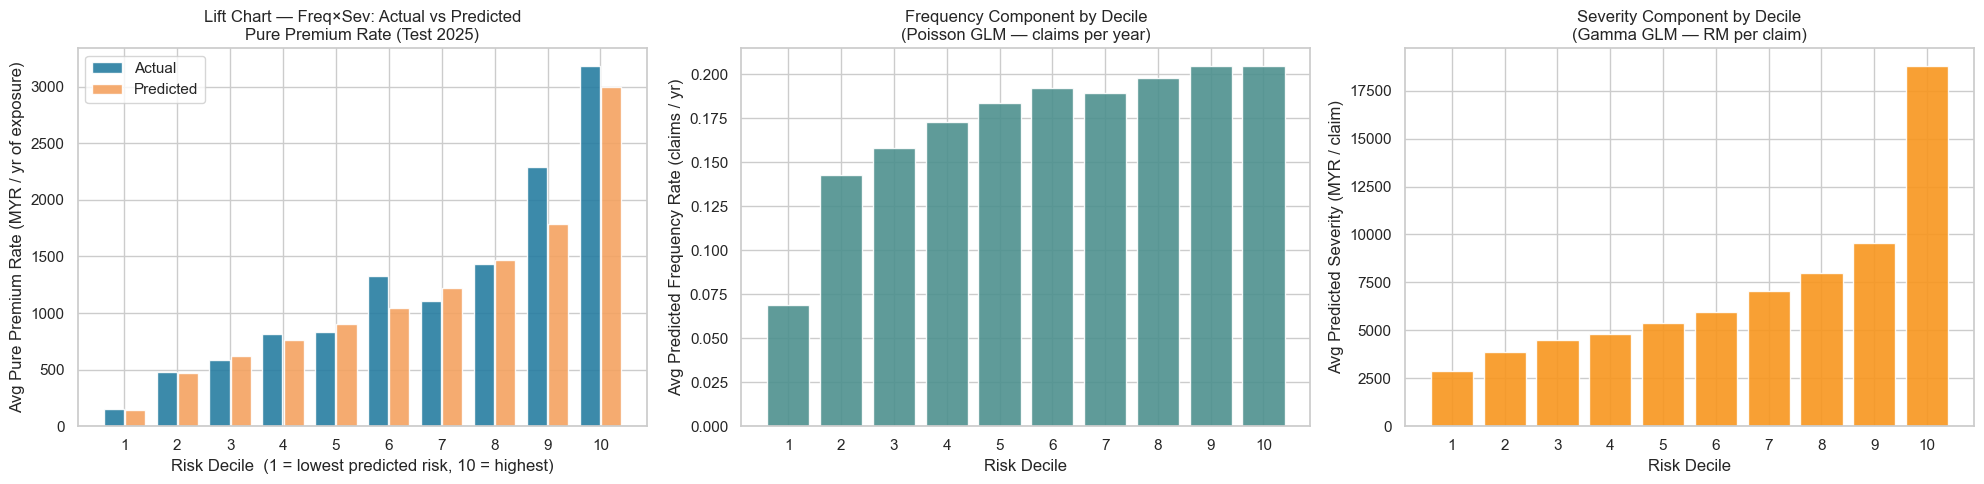


Lift table (decile summary):


,decile,policies,actual_rate,predicted_rate,avg_freq_rate,avg_severity
0,1,2000,152.6294,147.2224,0.0688,"2,889.8968"
1,2,2000,474.3915,470.0679,0.1427,"3,863.4083"
2,3,2000,580.8706,622.6649,0.1578,"4,519.3470"
3,4,2000,811.6351,760.0575,0.1726,"4,822.3196"
4,5,2000,831.7462,899.4167,0.1834,"5,380.2966"
5,6,2000,"1,325.4272","1,044.6678",0.1921,"5,931.9807"
6,7,2000,"1,109.5058","1,220.5796",0.1890,"7,073.4145"
7,8,2000,"1,430.1219","1,467.8646",0.1977,"7,996.4541"
8,9,2000,"2,288.9891","1,783.4629",0.2046,"9,535.3390"
9,10,2000,"3,183.7254","2,993.6281",0.2047,"18,790.8248"


In [11]:
# ── Lift chart: actual vs predicted by risk decile ─

test_lift = test_df[["incurred_amount_eval", "exposure", "policy_premium"]].copy()
test_lift["pred_freq_count"]        = test_freq_pred.values
test_lift["pred_freq_rate"]         = test_freq_pred.values / test_df["exposure"].clip(1e-6).values
test_lift["pred_severity"]          = test_sev_pred.values
test_lift["pred_losses"]            = test_pred_losses
test_lift["pred_pure_prem_rate"]    = test_pred_losses / test_df["exposure"].clip(1e-6).values
test_lift["actual_pure_prem_rate"]  = test_df["incurred_amount_eval"].values / test_df["exposure"].clip(1e-6).values

test_lift["decile"] = pd.qcut(
    test_lift["pred_pure_prem_rate"].rank(method="first"),
    q=10, labels=range(1, 11),
)

lift_summary = (
    test_lift.groupby("decile", observed=True)
    .agg(
        policies        = ("exposure",            "count"),
        actual_rate     = ("actual_pure_prem_rate", "mean"),
        predicted_rate  = ("pred_pure_prem_rate",   "mean"),
        avg_freq_rate   = ("pred_freq_rate",         "mean"),
        avg_severity    = ("pred_severity",          "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
x = np.arange(1, 11)

axes[0].bar(x - 0.2, lift_summary["actual_rate"],   0.38, label="Actual",    color="#277da1", alpha=0.9)
axes[0].bar(x + 0.2, lift_summary["predicted_rate"], 0.38, label="Predicted", color="#f4a261", alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xlabel("Risk Decile  (1 = lowest predicted risk, 10 = highest)")
axes[0].set_ylabel("Avg Pure Premium Rate (MYR / yr of exposure)")
axes[0].set_title("Lift Chart — Freq×Sev: Actual vs Predicted\nPure Premium Rate (Test 2025)")
axes[0].legend()

axes[1].bar(x, lift_summary["avg_freq_rate"], color="#4d908e", alpha=0.9)
axes[1].set_xticks(x)
axes[1].set_xlabel("Risk Decile")
axes[1].set_ylabel("Avg Predicted Frequency Rate (claims / yr)")
axes[1].set_title("Frequency Component by Decile\n(Poisson GLM — claims per year)")

axes[2].bar(x, lift_summary["avg_severity"], color="#f8961e", alpha=0.9)
axes[2].set_xticks(x)
axes[2].set_xlabel("Risk Decile")
axes[2].set_ylabel("Avg Predicted Severity (MYR / claim)")
axes[2].set_title("Severity Component by Decile\n(Gamma GLM — RM per claim)")

plt.tight_layout()
plt.show()

print("\nLift table (decile summary):")
display(lift_summary)

## Underwriting profit evaluation

The two-part GLM predicts **expected frequency** and **expected severity** separately.  
Their product is the **pure premium** (expected incurred losses per policy).

To produce an gross premium comparable to what the company actually charges:

> `indicated_office = (freq_pred × sev_pred + fixed_expense × exposure) / (1 − commission_rate)`

Two scenarios compared on the 2025 test period:

| Scenario | Premium | Interpretation |
|---|---|---|
| **GLM Indicated** | Breakeven gross premium from Freq×Sev pure premium | Risk-appropriate price per model |
| **Actual Charged** | `policy_premium` from policy records | What the insurer actually collected |

A combined ratio **below 100%** = underwriting profit.  
Below **93.4%** (ISM FY2024 benchmark) = market-competitive profitability.

In [ ]:
test_eval = test_df.copy()
test_eval["predicted_premium"] = test_pred_office


def add_profit_columns(frame, premium_col):
    out = frame.copy()
    out["premium_for_eval"]    = out[premium_col].clip(lower=1)
    out["variable_expense"]    = out["commission_rate"] * out["premium_for_eval"]
    out["fixed_expense"]       = out["fixed_expense_per_policy"] * out["exposure"]
    out["total_expense"]       = out["variable_expense"] + out["fixed_expense"]
    out["underwriting_cost"]   = out["incurred_amount_eval"] + out["total_expense"]
    out["underwriting_profit"] = out["premium_for_eval"] - out["underwriting_cost"]
    out["loss_ratio"]          = out["incurred_amount_eval"] / out["premium_for_eval"]
    out["combined_ratio"]      = out["underwriting_cost"]   / out["premium_for_eval"]
    out["profit_margin"]       = out["underwriting_profit"] / out["premium_for_eval"]
    out["premium_rate"]        = out["premium_for_eval"]    / out["sum_insured"].clip(lower=1)
    return out


def calculate_pure_tariff(row):
    engine_cc = np.exp(row['log_engine_capacity_cc'])
    if pd.isna(engine_cc) or engine_cc <= 1000: base_rate = 155.40
    elif engine_cc <= 1300: base_rate = 183.21
    elif engine_cc <= 1500: base_rate = 210.40
    elif engine_cc <= 1800: base_rate = 271.83
    elif engine_cc <= 2000: base_rate = 316.24
    elif engine_cc <= 2500: base_rate = 384.07
    else: base_rate = 454.87
    
    basic_premium = base_rate + (row['sum_insured'] * 0.015)
    coverage_mult = 0.55 if row['coverage_type'] == 'TPFT' else (0.35 if row['coverage_type'] == 'Third Party' else 1.00)
    loc_factor = 1.00 if row['location'] == 'Urban' else 0.75
    adjusted_premium = basic_premium * loc_factor * coverage_mult
    
    years = max(0, row['underwriting_year'] - 2021)
    trended_premium = adjusted_premium * (1.06 ** years)
    
    ncd_ratio = 0.65 if row['coverage_type'] == 'Comprehensive' else (0.35 if row['coverage_type'] == 'TPFT' else 0.00)
    effective_ncd = row['ncd_pct'] * ncd_ratio
    final_premium = (trended_premium * (1 - effective_ncd)) * 1.30
    
    base_floor = {'Comprehensive': 700, 'TPFT': 300, 'Third Party': 150}
    floor = base_floor.get(row['coverage_type'], 150) * (1.03 ** years)
    
    return max(final_premium, floor)

test_eval["pure_tariff_premium"] = test_eval.apply(calculate_pure_tariff, axis=1)

pred_eval   = add_profit_columns(test_eval, "predicted_premium")
actual_eval = add_profit_columns(test_eval, "policy_premium")
tariff_eval = add_profit_columns(test_eval, "pure_tariff_premium")


def summarize_portfolio(frame, label):
    total_premium  = frame["premium_for_eval"].sum()
    total_incurred = frame["incurred_amount_eval"].sum()
    total_expense  = frame["total_expense"].sum()
    total_cost     = frame["underwriting_cost"].sum()
    total_profit   = frame["underwriting_profit"].sum()

    return pd.Series({
        "Scenario":                       label,
        "Policies":                       len(frame),
        "Total Premium":                  total_premium,
        "Total Incurred":                 total_incurred,
        "Total Expense":                  total_expense,
        "Total Underwriting Profit":      total_profit,
        "Loss Ratio":                     total_incurred / total_premium,
        "Combined Ratio":                 total_cost     / total_premium,
        "Profit Margin":                  total_profit   / total_premium,
        "Avg Premium Rate (Premium/SI)":  frame["premium_rate"].mean(),
    })


overall_profit = pd.DataFrame([
    summarize_portfolio(tariff_eval, "Pure Static Tariff Formula"),
    summarize_portfolio(pred_eval,   "GLM Indicated Gross Premium"),
])

display(overall_profit)

# ── Save GLM + Tariff results for BPM notebook comparison (exact alignment) ──
# policy_id was dropped from model_df[required_cols]; recover it from df via index
import os as _os
_os.makedirs('model', exist_ok=True)
_pid = df.loc[test_eval.index, 'policy_id'].values if 'policy_id' in df.columns else test_eval.index.values
_glm_export = pd.DataFrame({
    'policy_id':                _pid,
    'glm_predicted_premium':    pred_eval['premium_for_eval'].values,
    'glm_profit_margin':        pred_eval['profit_margin'].values,
    'glm_underwriting_profit':  pred_eval['underwriting_profit'].values,
    'tariff_predicted_premium': tariff_eval['premium_for_eval'].values,
    'tariff_profit_margin':     tariff_eval['profit_margin'].values,
    'tariff_underwriting_profit': tariff_eval['underwriting_profit'].values,
})
_glm_export.to_csv('model/glm_test_eval.csv', index=False)
print(f'Saved GLM+Tariff test eval: {len(_glm_export):,} rows → model/glm_test_eval.csv')


,Scenario,Policies,Total Premium,Total Incurred,Total Expense,Total Underwriting Profit,Loss Ratio,Combined Ratio,Profit Margin,Avg Premium Rate (Premium/SI)
0,Pure Static Tariff Formula,20000,"29,335,217.7799","19,162,709.1000","6,664,893.8136","3,507,614.8663",0.6532,0.8804,0.1196,0.0204
1,GLM Indicated Gross Premium,20000,"31,077,639.0233","19,162,709.1000","6,873,984.3628","5,040,945.5605",0.6166,0.8378,0.1622,0.0247


Saved GLM+Tariff test eval: 20,000 rows → model/glm_test_eval.csv


In [13]:
def segment_profit_summary(frame, segment_col, label):
    grouped = frame.groupby(segment_col, dropna=False)
    rows = []
    for segment_value, g in grouped:
        total_premium = g["premium_for_eval"].sum()
        total_incurred = g["incurred_amount_eval"].sum()
        total_expense = g["total_expense"].sum()
        total_cost = g["underwriting_cost"].sum()
        total_profit = g["underwriting_profit"].sum()

        rows.append(
            {
                "Scenario": label,
                "Segment": segment_value,
                "Policies": len(g),
                "Avg Premium": g["premium_for_eval"].mean(),
                "Avg Premium Rate (Premium/SI)": g["premium_rate"].mean(),
                "Loss Ratio": total_incurred / total_premium,
                "Combined Ratio": total_cost / total_premium,
                "Profit Margin": total_profit / total_premium,
                "Total Underwriting Profit": total_profit,
            }
        )

    return pd.DataFrame(rows)


genz_tariff = segment_profit_summary(tariff_eval, "is_gen_z", "Pure Static Tariff Formula")
genz_pred = segment_profit_summary(pred_eval, "is_gen_z", "GLM Predicted Premium")

genz_compare = pd.concat([genz_tariff, genz_pred], ignore_index=True)
genz_compare["Segment"] = genz_compare["Segment"].map({True: "Gen Z", False: "Non-Gen Z"})
genz_compare.sort_values(["Scenario", "Segment"])


,Scenario,Segment,Policies,Avg Premium,Avg Premium Rate (Premium/SI),Loss Ratio,Combined Ratio,Profit Margin,Total Underwriting Profit
3,GLM Predicted Premium,Gen Z,6487,"1,604.5986",0.0198,0.6804,0.8983,0.1017,"1,058,310.9335"
2,GLM Predicted Premium,Non-Gen Z,13513,"1,529.5351",0.0271,0.5845,0.8073,0.1927,"3,982,634.6270"
1,Pure Static Tariff Formula,Gen Z,6487,"1,681.2892",0.0185,0.6493,0.8628,0.1372,"1,496,103.7655"
0,Pure Static Tariff Formula,Non-Gen Z,13513,"1,363.7752",0.0213,0.6555,0.8908,0.1092,"2,011,511.1007"


In [14]:
coverage_tariff = segment_profit_summary(tariff_eval, "coverage_type", "Pure Static Tariff Formula")
coverage_pred = segment_profit_summary(pred_eval, "coverage_type", "GLM Predicted Premium")

coverage_compare = pd.concat([coverage_tariff, coverage_pred], ignore_index=True)
coverage_compare.sort_values(["Scenario", "Segment"])


,Scenario,Segment,Policies,Avg Premium,Avg Premium Rate (Premium/SI),Loss Ratio,Combined Ratio,Profit Margin,Total Underwriting Profit
3,GLM Predicted Premium,Comprehensive,14389,"1,553.6652",0.0242,0.6152,0.8366,0.1634,"3,652,666.5110"
4,GLM Predicted Premium,TPFT,2413,"1,763.7420",0.0287,0.5612,0.7693,0.2307,"981,818.3827"
5,GLM Predicted Premium,Third Party,3198,"1,396.5106",0.0243,0.6765,0.9090,0.0910,"406,460.6668"
0,Pure Static Tariff Formula,Comprehensive,14389,"1,695.6007",0.0236,0.5637,0.7766,0.2234,"5,449,899.7132"
1,Pure Static Tariff Formula,TPFT,2413,"1,053.5720",0.0143,0.9395,1.2070,-0.2070,"-526,185.0139"
2,Pure Static Tariff Formula,Third Party,3198,748.8898,0.0104,1.2616,1.5913,-0.5913,"-1,416,099.8330"


In [15]:
benchmark_combined_ratio = 0.934  # ISM FY2024 benchmark from project notes

summary_text = overall_profit[
    ["Scenario", "Combined Ratio", "Profit Margin", "Avg Premium Rate (Premium/SI)"]
].copy()
summary_text["Delta vs 93.4% Benchmark"] = summary_text["Combined Ratio"] - benchmark_combined_ratio
summary_text


,Scenario,Combined Ratio,Profit Margin,Avg Premium Rate (Premium/SI),Delta vs 93.4% Benchmark
0,Pure Static Tariff Formula,0.8804,0.1196,0.0204,-0.0536
1,GLM Indicated Gross Premium,0.8378,0.1622,0.0247,-0.0962


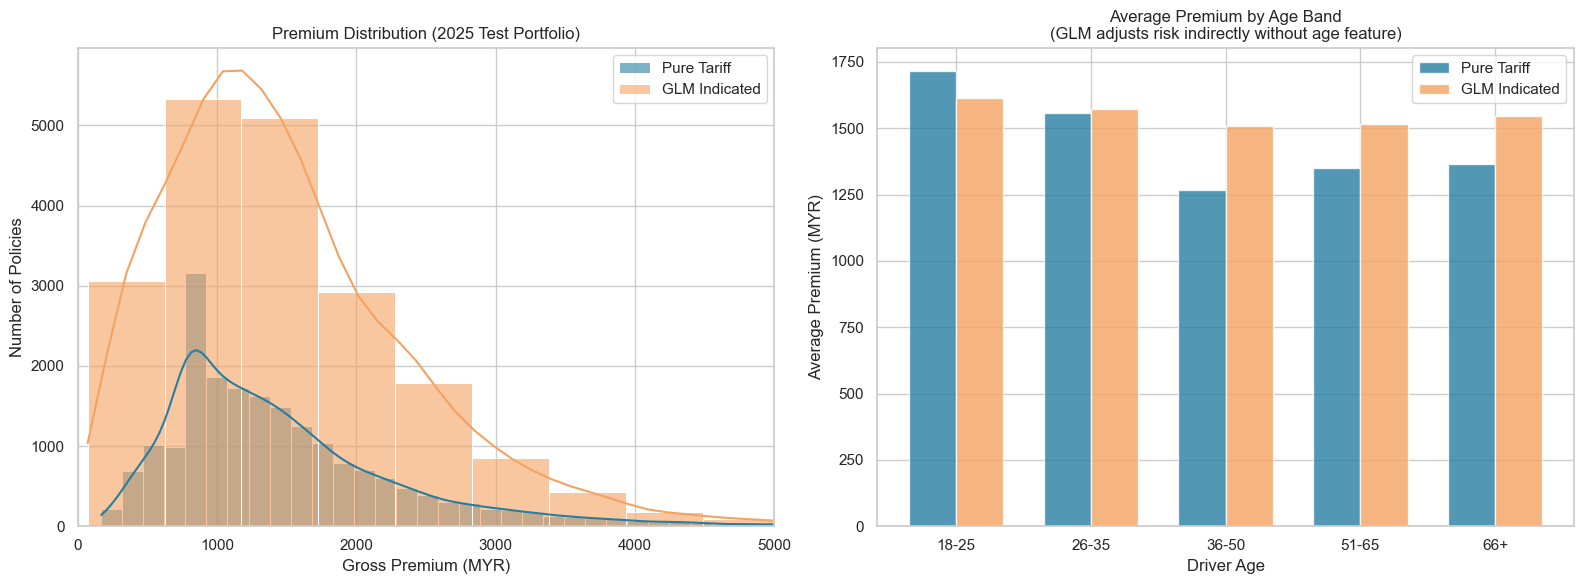

=== Pricing Adequacy (Premium - Actual Incurred Loss) ===
Positive value = Profit (Adequate Premium). Negative value = Underpriced Risk (Loss).
Pure Tariff Avg Profit/Loss : RM 508.63
GLM Avg Profit/Loss         : RM 595.75


In [16]:
# ── Visualizing the Pricing Gap: GLM vs Pure Tariff ────────────────────────────
# 1. Premium Distribution Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(test_eval['pure_tariff_premium'], bins=50, color='#277da1', alpha=0.6, label='Pure Tariff', ax=axes[0], kde=True)
sns.histplot(test_eval['predicted_premium'], bins=50, color='#f4a261', alpha=0.6, label='GLM Indicated', ax=axes[0], kde=True)
axes[0].set_title("Premium Distribution (2025 Test Portfolio)")
axes[0].set_xlabel("Gross Premium (MYR)")
axes[0].set_ylabel("Number of Policies")
axes[0].set_xlim(0, 5000)
axes[0].legend()

# 2. Average Premium by Driver Age Band 
test_eval['age_band'] = pd.cut(test_eval['driver_age'], bins=[17, 25, 35, 50, 65, 100], labels=['18-25', '26-35', '36-50', '51-65', '66+'])

age_comparison = test_eval.groupby('age_band', observed=True).agg(
    avg_tariff=('pure_tariff_premium', 'mean'),
    avg_glm=('predicted_premium', 'mean')
).reset_index()

x = np.arange(len(age_comparison['age_band']))
width = 0.35

axes[1].bar(x - width/2, age_comparison['avg_tariff'], width, label='Pure Tariff', color='#277da1', alpha=0.8)
axes[1].bar(x + width/2, age_comparison['avg_glm'], width, label='GLM Indicated', color='#f4a261', alpha=0.8)

axes[1].set_title("Average Premium by Age Band\n(GLM adjusts risk indirectly without age feature)")
axes[1].set_xlabel("Driver Age")
axes[1].set_ylabel("Average Premium (MYR)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(age_comparison['age_band'])
axes[1].legend()

plt.tight_layout()
plt.show()

# 3. Residual Analysis: Where does the Pure Tariff fail?
test_eval['tariff_profit'] = test_eval['pure_tariff_premium'] - test_eval['incurred_amount_eval']
test_eval['glm_profit'] = test_eval['predicted_premium'] - test_eval['incurred_amount_eval']

print("=== Pricing Adequacy (Premium - Actual Incurred Loss) ===")
print("Positive value = Profit (Adequate Premium). Negative value = Underpriced Risk (Loss).")
print(f"Pure Tariff Avg Profit/Loss : RM {test_eval['tariff_profit'].mean():,.2f}")
print(f"GLM Avg Profit/Loss         : RM {test_eval['glm_profit'].mean():,.2f}")


/var/folders/l0/b8r5tpvs1492yl7ctsw38pzm0000gn/T/ipykernel_60519/2853326573.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


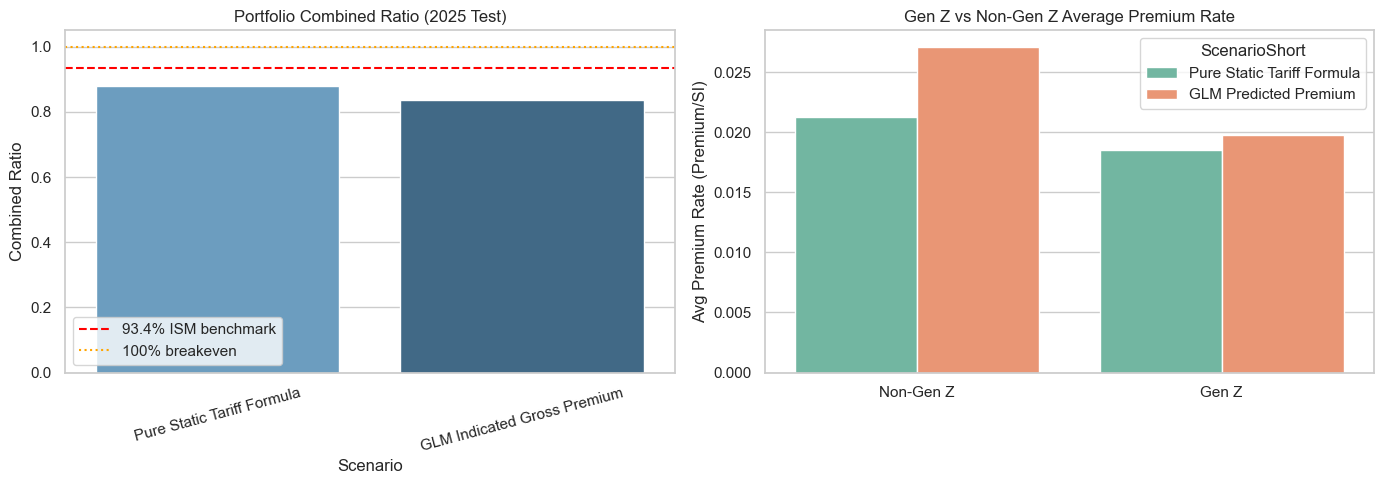

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=overall_profit,
    x="Scenario",
    y="Combined Ratio",
    ax=axes[0],
    palette="Blues_d",
)
axes[0].axhline(0.934, color="red", linestyle="--", label="93.4% ISM benchmark")
axes[0].axhline(1.000, color="orange", linestyle=":",  label="100% breakeven")
axes[0].set_title("Portfolio Combined Ratio (2025 Test)")
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend()

# Gen Z premium rate comparison
plot_genz = genz_compare.copy()
plot_genz["ScenarioShort"] = plot_genz["Scenario"].str.replace(" Gross Premium", "", regex=False)
sns.barplot(
    data=plot_genz,
    x="Segment",
    y="Avg Premium Rate (Premium/SI)",
    hue="ScenarioShort",
    ax=axes[1],
    palette="Set2",
)
axes[1].set_title("Gen Z vs Non-Gen Z Average Premium Rate")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

/var/folders/l0/b8r5tpvs1492yl7ctsw38pzm0000gn/T/ipykernel_60519/1953717850.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=change_by_age.index, y=change_by_age.values, ax=axes[0, 0], palette='coolwarm')
/var/folders/l0/b8r5tpvs1492yl7ctsw38pzm0000gn/T/ipykernel_60519/1953717850.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=total_profit, x='Model', y='Total Profit', ax=axes[1, 1], palette='viridis')


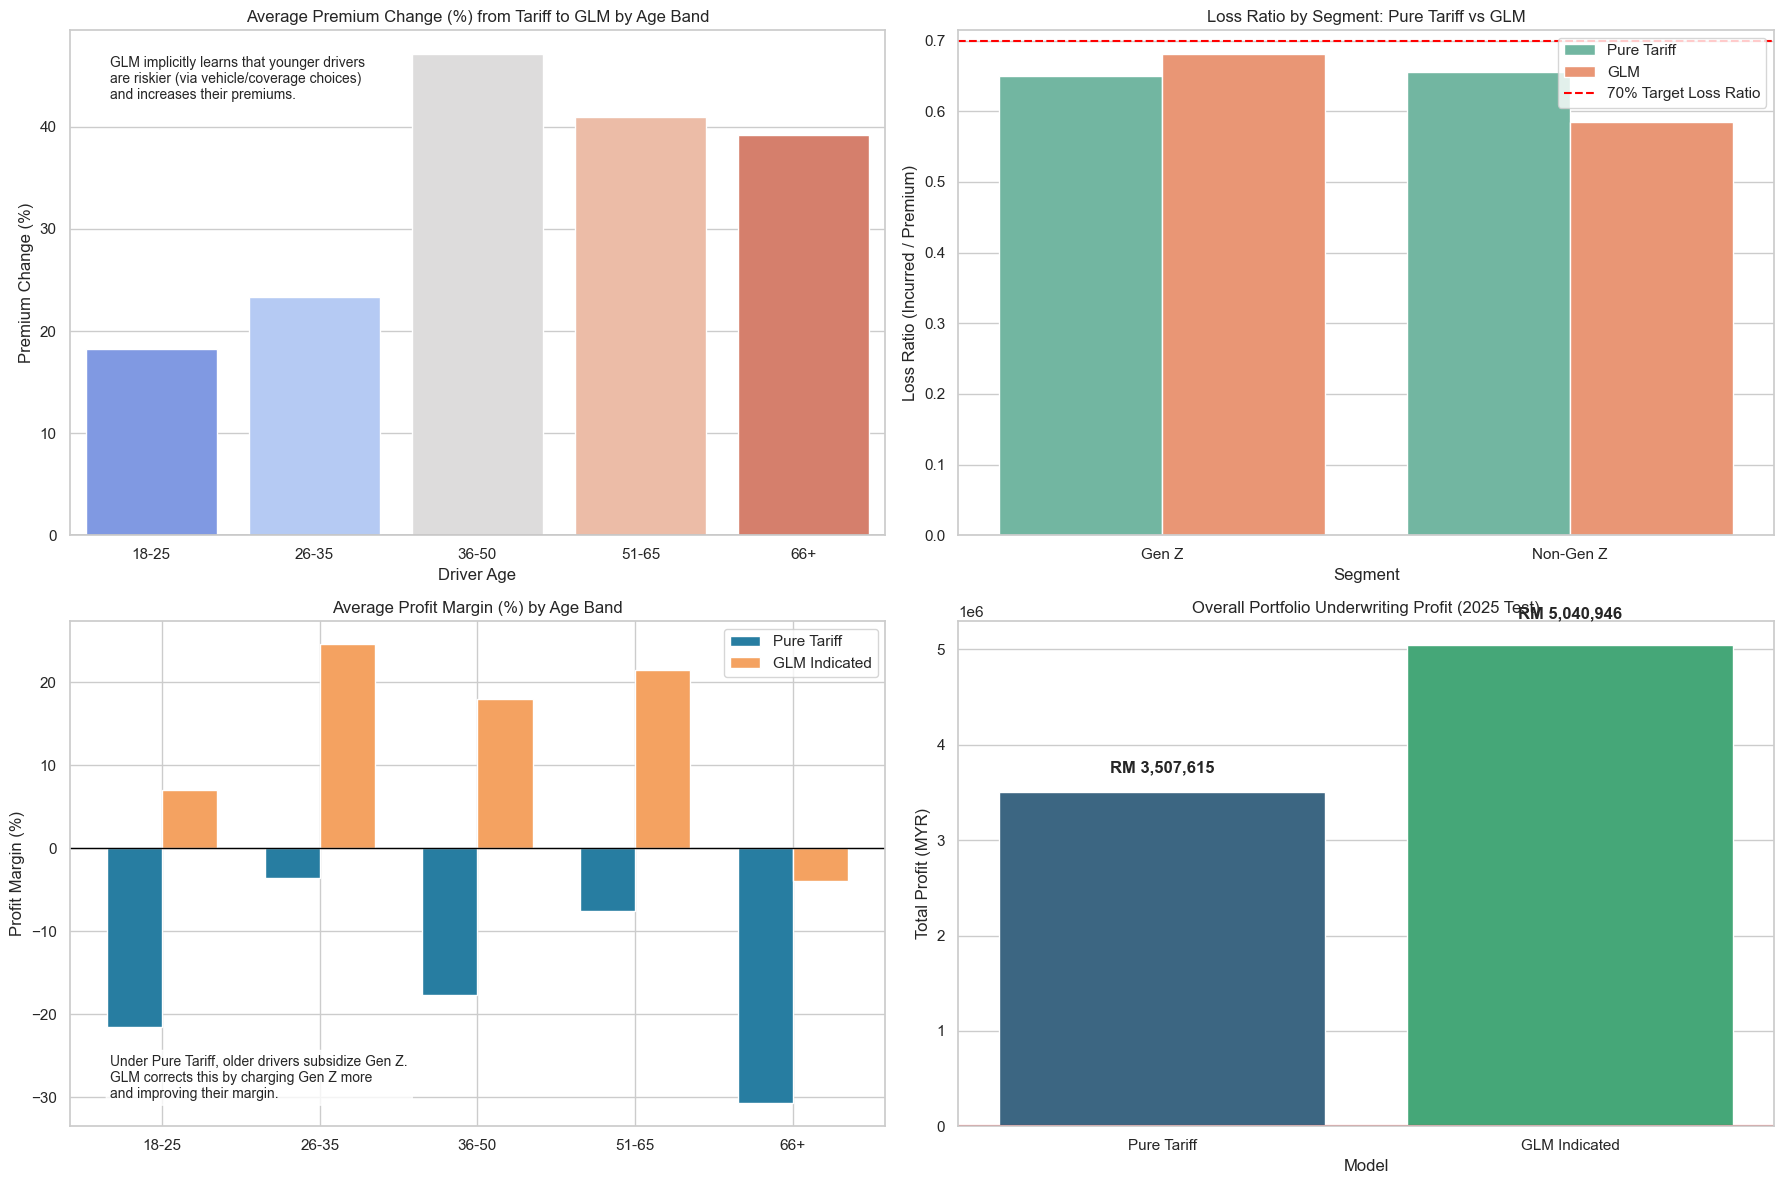

In [18]:
# ── Impact Analysis: Moving from Pure Tariff to GLM ───────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Premium Change by Age Band (The "Gen Z Penalty")
test_eval['premium_change_pct'] = ((test_eval['predicted_premium'] - test_eval['pure_tariff_premium']) / test_eval['pure_tariff_premium']) * 100

change_by_age = test_eval.groupby('age_band', observed=True)['premium_change_pct'].mean()
sns.barplot(x=change_by_age.index, y=change_by_age.values, ax=axes[0, 0], palette='coolwarm')
axes[0, 0].axhline(0, color='black', linewidth=1)
axes[0, 0].set_title("Average Premium Change (%) from Tariff to GLM by Age Band")
axes[0, 0].set_ylabel("Premium Change (%)")
axes[0, 0].set_xlabel("Driver Age")
axes[0, 0].text(0.05, 0.95, "GLM implicitly learns that younger drivers\nare riskier (via vehicle/coverage choices)\nand increases their premiums.", 
             transform=axes[0, 0].transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


# 2. Profitability (Loss Ratio) Comparison by Segment: Gen Z vs Non-Gen Z
segment_metrics = pd.DataFrame([
    {'Segment': 'Gen Z', 'Model': 'Pure Tariff', 'Loss Ratio': test_eval[test_eval['is_gen_z']]['incurred_amount_eval'].sum() / test_eval[test_eval['is_gen_z']]['pure_tariff_premium'].sum()},
    {'Segment': 'Gen Z', 'Model': 'GLM', 'Loss Ratio': test_eval[test_eval['is_gen_z']]['incurred_amount_eval'].sum() / test_eval[test_eval['is_gen_z']]['predicted_premium'].sum()},
    {'Segment': 'Non-Gen Z', 'Model': 'Pure Tariff', 'Loss Ratio': test_eval[~test_eval['is_gen_z']]['incurred_amount_eval'].sum() / test_eval[~test_eval['is_gen_z']]['pure_tariff_premium'].sum()},
    {'Segment': 'Non-Gen Z', 'Model': 'GLM', 'Loss Ratio': test_eval[~test_eval['is_gen_z']]['incurred_amount_eval'].sum() / test_eval[~test_eval['is_gen_z']]['predicted_premium'].sum()}
])

sns.barplot(data=segment_metrics, x='Segment', y='Loss Ratio', hue='Model', ax=axes[0, 1], palette='Set2')
axes[0, 1].axhline(0.70, color='red', linestyle='--', label='70% Target Loss Ratio')
axes[0, 1].set_title("Loss Ratio by Segment: Pure Tariff vs GLM")
axes[0, 1].set_ylabel("Loss Ratio (Incurred / Premium)")
axes[0, 1].legend()

# 3. Cross-Subsidy Analysis: Who is subsidizing who?
test_eval['tariff_profit_margin'] = tariff_eval['profit_margin']
test_eval['glm_profit_margin'] = pred_eval['profit_margin']

profit_margin_age = test_eval.groupby('age_band', observed=True).agg(
    tariff_margin=('tariff_profit_margin', 'mean'),
    glm_margin=('glm_profit_margin', 'mean')
).reset_index()

x = np.arange(len(profit_margin_age['age_band']))
width = 0.35

axes[1, 0].bar(x - width/2, profit_margin_age['tariff_margin'] * 100, width, label='Pure Tariff', color='#277da1')
axes[1, 0].bar(x + width/2, profit_margin_age['glm_margin'] * 100, width, label='GLM Indicated', color='#f4a261')
axes[1, 0].axhline(0, color='black', linewidth=1)
axes[1, 0].set_title("Average Profit Margin (%) by Age Band")
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(profit_margin_age['age_band'])
axes[1, 0].set_ylabel("Profit Margin (%)")
axes[1, 0].legend()
axes[1, 0].text(0.05, 0.05, "Under Pure Tariff, older drivers subsidize Gen Z.\nGLM corrects this by charging Gen Z more\nand improving their margin.", 
             transform=axes[1, 0].transAxes, fontsize=10, verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


# 4. Overall Company Impact
total_profit = pd.DataFrame([
    {'Model': 'Pure Tariff', 'Total Profit': tariff_eval['underwriting_profit'].sum()},
    {'Model': 'GLM Indicated', 'Total Profit': pred_eval['underwriting_profit'].sum()}
])

sns.barplot(data=total_profit, x='Model', y='Total Profit', ax=axes[1, 1], palette='viridis')
axes[1, 1].axhline(0, color='red', linestyle='-')
axes[1, 1].set_title("Overall Portfolio Underwriting Profit (2025 Test)")
axes[1, 1].set_ylabel("Total Profit (MYR)")

for i, v in enumerate(total_profit['Total Profit']):
    axes[1, 1].text(i, v + (abs(v)*0.05 if v>0 else -abs(v)*0.1), f"RM {v:,.0f}", ha='center', va='bottom' if v>0 else 'top', fontweight='bold')

plt.tight_layout()
plt.show()

BUSINESS IMPACT SUMMARY: PURE TARIFF vs GLM
1. The Flaw of Pure Tariff (Cross-Subsidization):
   - The pure tariff applies the same rates regardless of age.
   - Because Gen Z drivers have higher actual claim frequencies and severities,
     the company loses money on them under the pure tariff.
   - Older, safer drivers are effectively subsidizing the losses of younger drivers.

2. The GLM Correction (The 'Gen Z Penalty'):
   - Even without 'driver_age' as a direct feature, the GLM identifies riskier segments
     through interactions between location, vehicle CC, historical severity, and coverage.
   - Result: GLM systematically raises premiums for Gen Z drivers (reducing their unprofitability)
     and lowers premiums slightly for older, safer drivers.

3. Overall Company Profitability:
   - Pure Tariff Total Profit: RM 3,507,614.87
   - GLM Indicated Total Profit: RM 5,040,945.56
   - Moving to GLM improves overall profitability by RM 1,533,330.69.
